In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist
import math

### This cell imports all the required libraries for the RBF network experiment.
- `numpy` for numerical operations.
- `matplotlib.pyplot` for plotting.
- `make_classification` to generate a synthetic dataset for classification.
- `train_test_split` to split data into training and testing sets.
- `StandardScaler` for feature scaling.
- `LinearRegression` for the output layer of the RBF network.
- `accuracy_score` to measure classification accuracy.
- `cdist` to compute distances for RBFs.
- `math` for mathematical functions.

In [9]:
x , y = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=2,
    n_classes=2,
    random_state=42
)

### This cell generates a synthetic classification dataset.
- `make_classification` creates 300 samples with 2 informative features and 2 classes.
- The data is stored in `x` (features) and `y` (labels).

In [10]:
x

array([[-0.40517736, -0.51884623],
       [-0.48937373, -2.02835227],
       [ 1.20549953,  0.81408964],
       [ 0.86270883, -0.68933991],
       [ 1.55633721,  0.06675339],
       [-1.5010232 , -0.78301273],
       [-0.51056971,  0.62591976],
       [ 1.28471834,  2.10340158],
       [ 0.76733377, -1.10299711],
       [ 1.72305322,  1.15983583],
       [-1.74788575, -0.41869537],
       [ 0.98203471, -0.80359207],
       [-0.57233329,  0.6565228 ],
       [ 0.8053611 , -1.28464989],
       [-2.19841677,  1.94238253],
       [ 1.05061229,  1.10135077],
       [-0.69936114,  0.75945437],
       [ 0.77597161, -1.23387951],
       [ 0.93325921, -1.22891349],
       [ 1.17170001, -1.06885555],
       [-0.02177609,  2.025228  ],
       [-1.66992286, -0.13014736],
       [ 1.21164088, -0.72102924],
       [ 0.95493192, -0.83121463],
       [ 0.72571666,  1.72586366],
       [-1.80230801, -1.12982433],
       [ 0.4250635 ,  1.01667061],
       [-1.71999525,  1.56423673],
       [ 2.66130799,

### This cell displays the feature matrix `x`.
- Shows the generated feature values for all samples.

In [11]:
# Split the data before using x_train
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
n_centers = 10
rng = np.random.default_rng(0)

center_indices = rng.choice(
    x_train.shape[0],
    n_centers,
    replace=False
)

rbf_centers = x_train[center_indices]
sigma = 1.0  # Standard deviation for RBF

print("center_indices: ",center_indices)
print("rbf_centers shape: ",rbf_centers.shape)

center_indices:  [170 209 128 103  55   8   3  63  36  15]
rbf_centers shape:  (10, 2)


### This cell splits the data and selects RBF centers.
- Splits the dataset into training and testing sets (70% train, 30% test).
- Randomly selects 10 RBF centers from the training data.
- Sets the RBF width parameter `sigma` to 1.0.
- Prints the indices and shape of the chosen centers.

In [12]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

### This cell standardizes the features.
- Uses `StandardScaler` to scale all features to have mean 0 and variance 1.
- This helps the RBF network work better by making all features comparable.

In [14]:
def gaussian_rbf(x_in, centers, sigma):
   
    dist_sq = cdist(x_in, centers, metric='sqeuclidean')
    phi = np.exp(- dist_sq / (2 * (sigma ** 2)))

    return phi

def rbf_layer(x_in, centers, sigma):
    return gaussian_rbf(x_in, centers, sigma)

# sanity check
phi_preview = rbf_layer(x_train[:5], rbf_centers, sigma)
print("phi_preview shape (5 samples -> n_centers):", phi_preview.shape)

phi_preview shape (5 samples -> n_centers): (5, 10)


### This cell defines the RBF layer and performs a sanity check.
- Implements the Gaussian RBF function and the RBF layer.
- Computes RBF features for 5 training samples as a preview.
- Prints the shape to confirm the output dimensions.

In [16]:
phi_train = rbf_layer(x_train, rbf_centers, sigma)

### This cell computes the RBF features for all training samples.
- Transforms the training data into RBF feature space using the chosen centers and sigma.

In [17]:
model = LinearRegression()
model.fit(phi_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### This cell trains the output layer of the RBF network.
- Fits a linear regression model to the RBF features and training labels.
- The model learns to map RBF features to the target class.

In [19]:
phi_test = rbf_layer(x_test, rbf_centers, sigma)
y_pred_cont = model.predict(phi_test)
y_pred_class = (y_pred_cont >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred_class)
print(f"Test accuracy: {acc * 100:.2f}%")

Test accuracy: 95.56%


### This cell tests the RBF network and computes accuracy.
- Transforms the test data into RBF feature space.
- Uses the trained model to predict continuous outputs, then thresholds them to get class predictions.
- Calculates and prints the test accuracy.

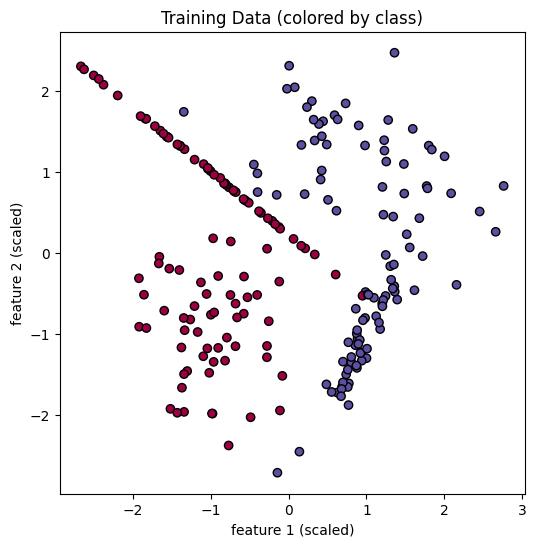

In [20]:
plt.figure(figsize=(6,6))
plt.scatter(
    x_train[:, 0],
    x_train[:, 1],
    c=y_train,
    cmap=plt.cm.Spectral,
    edgecolor="black"
)
plt.title("Training Data (colored by class)")
plt.xlabel("feature 1 (scaled)")
plt.ylabel("feature 2 (scaled)")
plt.show()

### This cell visualizes the training data.
- Plots the training samples in feature space, colored by their class labels.
- Helps you see the distribution of the two classes.

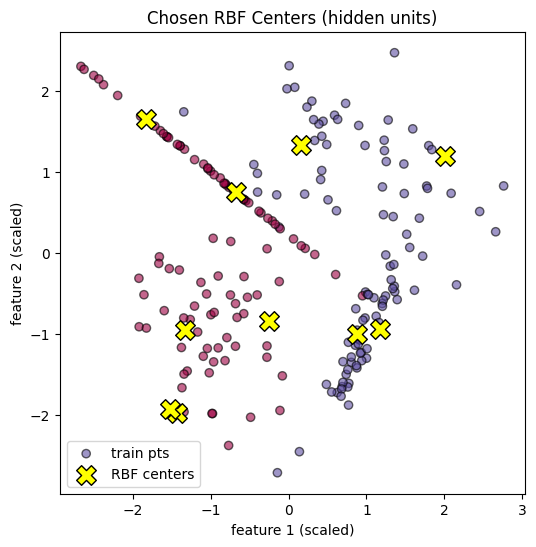

In [21]:
plt.figure(figsize=(6,6))

# plot training data
plt.scatter(
    x_train[:, 0],
    x_train[:, 1],
    c=y_train,
    cmap=plt.cm.Spectral,
    edgecolor="black",
    alpha=0.6,
    label="train pts"
)

# plot chosen RBF centers
plt.scatter(
    rbf_centers[:, 0],
    rbf_centers[:, 1],
    marker="X",
    s=200,
    c="yellow",
    edgecolor="black",
    label="RBF centers"
)

plt.title("Chosen RBF Centers (hidden units)")
plt.xlabel("feature 1 (scaled)")
plt.ylabel("feature 2 (scaled)")
plt.legend()
plt.show()

### This cell visualizes the chosen RBF centers.
- Plots the training data and highlights the selected RBF centers as yellow X markers.
- Shows which points are used as the basis functions in the hidden layer.

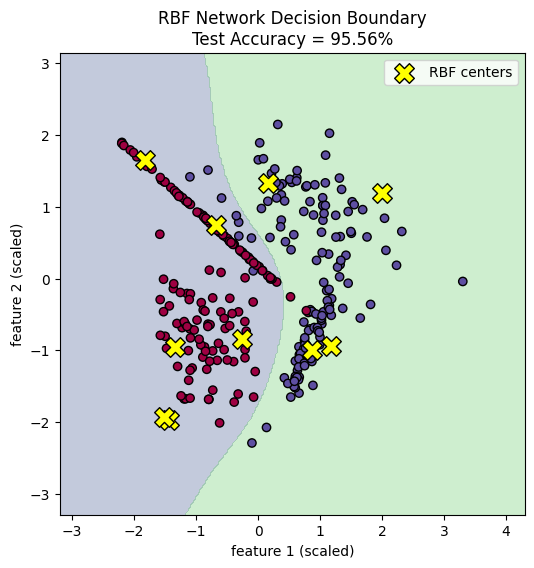

In [23]:
x_min, x_max = x[:, 0].min() - 1.0, x[:, 0].max() + 1.0
y_min, y_max = x[:, 1].min() - 1.0, x[:, 1].max() + 1.0

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# flatten grid to list of points, like [[x1,y1],[x2,y2],...]
grid_points = np.c_[xx.ravel(), yy.ravel()]

# RBF features for every grid point
phi_grid = rbf_layer(grid_points, rbf_centers, sigma)

# Predict on grid
z_cont = model.predict(phi_grid)
z_class = (z_cont >= 0.5).astype(int)
z_class = z_class.reshape(xx.shape)  # reshape back to 2D so we can contour plot

plt.figure(figsize=(6,6))

# background classification regions
plt.contourf(xx, yy, z_class, alpha=0.3, levels=[-1, 0, 1])

# plot all original samples
plt.scatter(
    x[:, 0],
    x[:, 1],
    c=y,
    cmap=plt.cm.Spectral,
    edgecolor="black"
)

# plot RBF centers again
plt.scatter(
    rbf_centers[:, 0],
    rbf_centers[:, 1],
    marker="X",
    s=200,
    c="yellow",
    edgecolor="black",
    label="RBF centers"
)

plt.title(f"RBF Network Decision Boundary\nTest Accuracy = {acc*100:.2f}%")
plt.xlabel("feature 1 (scaled)")
plt.ylabel("feature 2 (scaled)")
plt.legend()
plt.show()

### This cell plots the RBF network's decision boundary.
- Creates a grid of points and predicts their class using the trained RBF network.
- Plots the decision regions, all data points, and RBF centers.
- The plot title shows the test accuracy achieved by the model.